### **For this Project**

1. The Plan is for me to learn serious classification thinking.
2. I am to explore class imbalance properly
3. Use LRM, XGB, RFM and GB models
4. Compare metrics
5. Apply SMOTE or resampling threshold tuning

### **Typical Workflow for Classification Model**

1. Problem Definition
2. Data Loading and Inspection
3. Understanding the target variable and EDA
4. Train, Test Split + Scaling
5. Building a baseline models (without handling imbalance) and evaluate
6. Handle imbalance
7. Train models again and evaluate
8. Hyperparameter tuning with cross-validation
9. Threshold tuning
10. Feature Importance
11. Confusion Matrix
11. Summary, Model interpretation and Conclusion.


# ***Problem Definition***

### **Credit Card Fraud Detection Dataset 2023**

Description: It is important that credit card companies are able to recognise fraudulent credit card transactions so that customers are not charged for items that they did not purchase.
This dataset contains credit card transactions made by European cardholders in Sept 2013. It comprises of records where 492 out of 284,807 transactions are fraudulent. 

**The primary objective** is to development raud detection models to identify potentially fraudulent credit card transactions.

Key Features:
Time: this contains the seconds laps between each transaction and the first transaction in the dataset.
V1-V28: Anonymized features representing various transaction attributes (e.g., time, location, etc.). They were anonymised using PCA. Sensitive information removed to ensure privacy and compliance with ethical guidelines.
Amount: The transaction amount
Class: Binary label indicating whether the transaction is fraudulent (1) or not (0)



### **How a Classification Model Works**



A classification model tries to learn patterns in transaction behaviour that distinguish fraud from legitimate activity and those patterns exist inside the anonymized variables V1–V28.
In your fraud project the classes are:
0 → Normal transaction
1 → Fraudulent transaction

The model studies the datapoints and learns
> “What patterns usually appear when a transaction is fraud?”

Different algorithms learn this pattern in different ways.
1. Logistic Regression learns a mathematical boundary that separates fraud from normal transactions.
2. Random Forest learns many decision rules using trees.
3. XGBoost builds trees sequentially, each correcting the mistakes of the previous one.

But the final goal is to answer the question: Given a new transaction → predict fraud or normal

2. Classification models usually predict probabilities first.
Example output:
Transaction	Fraud Probability
Tx1	0.02
Tx2	0.11
Tx3	0.87

Then the probability is converted into a class using a threshold.
Default rule:
Probability ≥ 0.5 → Fraud
Probability < 0.5 → Normal
That is why threshold tuning exists.

3. Now, during training the model tries to minimize errors.
For every prediction:

Prediction	Actual	Result
Fraud	Fraud	Correct
Fraud	Normal	False Alarm
Normal	Fraud	Missed Fraud

The algorithm adjusts itself repeatedly to reduce mistakes.

4. Why Models Struggle With Imbalance is that if a data is heavily imbalance like in the case of this dataset, accuracy will be very high (as high as 99%) i.e. it will predict all transactions to be normal (because it will learn patterns primarily on the normal transactions since they are very dominant and there are very little fraud transactions), detect no frauds and the model becomes useless since its primary aim is to predict fraud tansaction.

5. Methods like SMOTE and CLass weight is then introduced to fix imbalance by creating synthetic fraud samples so that the model can learn patterns more accurately from both classes and give more quality predictions.

8. Recall is a measure of how many fraud cases did the model catches. Higher recall = fewer fraud cases missed.

9. Even after handling imbalance, the default threshold 0.5 may still not be ideal. Finding the ideal threshold that fits the data helps to even get a better recall score and that is why I will be doing threshold tuning subsequently.

# ***Data Loading and Inspection***

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/user/Desktop/SK/Data Science/Personal Projects/Credit Card Fraud Detection Dataset 2013/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Target is Class Column
0 = legitimate transactions 
1 = fraudulent transactions

The Features v1 to v28 are anonymised features. This means the original financial variables were transformed, privacy preserved.

No categorical encoding needed (since they are already all numerical), no scaling required and models are expected to train faster.

The amount feature is very important because fraud patterns often involves unusually large amounts and unusually small test transactions.

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Based on the above analysis, there are no missing values

# ***Understanding the target variable, features and General EDA***

Since I have 28 PC features, I was thinking since they are too much, that I can just find the ones that best correlates with the target and feeds just those ones to the model. But, then I realise the PCA creates PCs that are uncorrelated so the idea I had earlier would not work so the best thing to do would be to feed all features to the model and it would decided which of the features will take priority and I will see those specific features that takes prioroty subsequently when I do the fearure importance analysis.

The goal here is to:
1. Understand the target
2. Explore Time feature
3. Explore Amount feature
4. Inspect the general relationships between features and fraud.
5. Identify potential preprocessing needs.

#### Understanding the Target

In [7]:
#Checking the Target
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [8]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

This is a very good dataset because it accounts well for a big imbalance in classes. Confusion matrix accuracy is said not to be very useful for unbalanced classification so I will be measuring accuracy using Area Under Precision-Recall Curve (AUPRC)

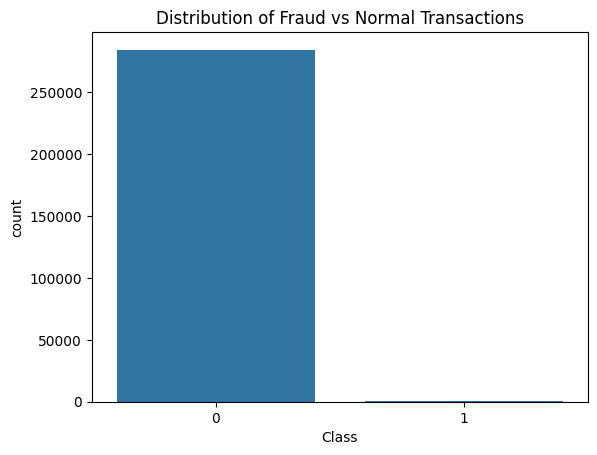

In [9]:
sns.countplot(x='Class', data=df)
plt.title("Distribution of Fraud vs Normal Transactions")
plt.show()

This shows that fraudulent transactions are extremely rare and the dataset is highly imbalanced.

#### Understanding the Amount feature

In [10]:
df['Amount'].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

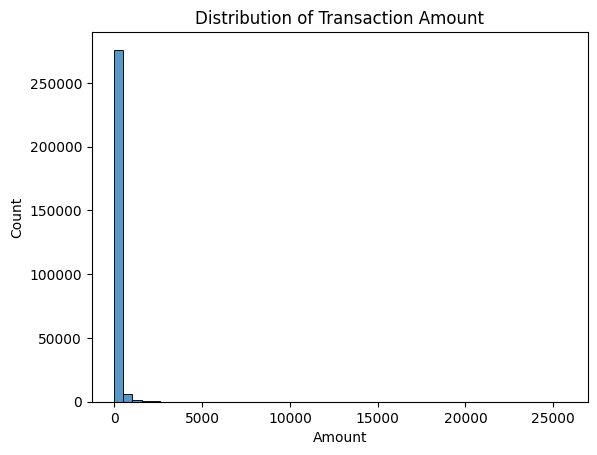

In [11]:
sns.histplot(df['Amount'], bins=50)
plt.title("Distribution of Transaction Amount")
plt.show()

Here I can see all the transactions are of amount less than 4000

<Axes: xlabel='Class', ylabel='Amount'>

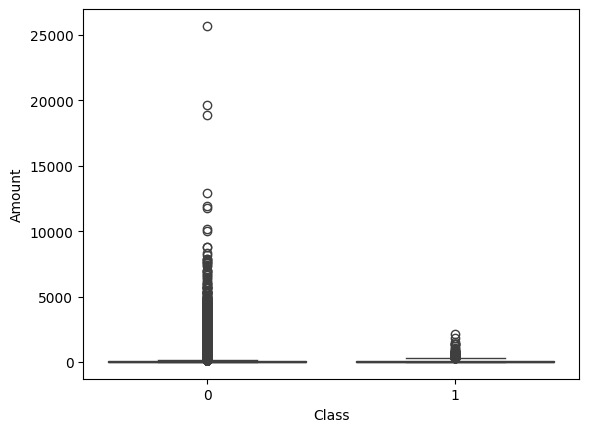

In [12]:
sns.boxplot(x='Class', y='Amount', data=df)

Here I see there are a few large transactions which are classified as none fraudulent but the fraudulent transactions are transcations less than 4000

#### Understanding the Time feature

Time contains the seconds laps between each transaction and the first transaction in the dataset.

<Axes: xlabel='Time', ylabel='Count'>

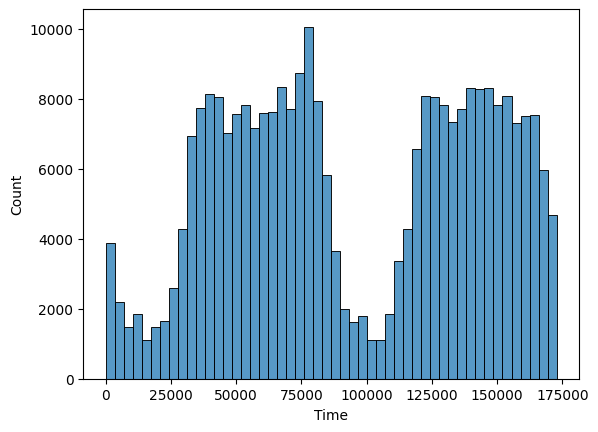

In [13]:
sns.histplot(df['Time'], bins=50)

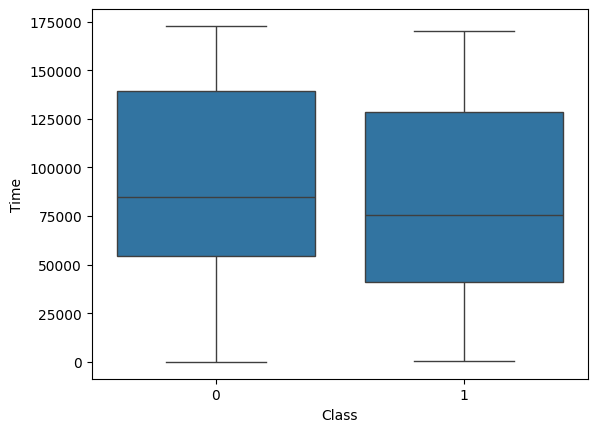

In [14]:
sns.boxplot(x='Class', y='Time', data=df)
plt.show()

Here I can see a big overlap between the time for Class 0 and CLass 1 so there is no big significant difference

#### Understanding the Correlation with Class

In [15]:
corr = df.corr()
corr['Class'].sort_values(ascending=False).head(10)

Class    1.000000
V11      0.154876
V4       0.133447
V2       0.091289
V21      0.040413
V19      0.034783
V20      0.020090
V8       0.019875
V27      0.017580
V28      0.009536
Name: Class, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

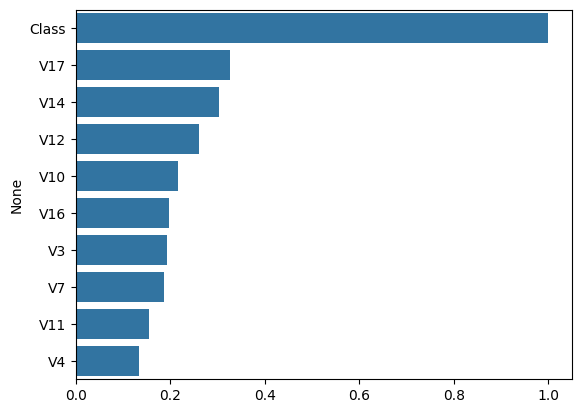

In [16]:
top_corr = corr['Class'].abs().sort_values(ascending=False).head(10)

sns.barplot(x=top_corr.values, y=top_corr.index)
plt.show

# ***Train, Test Split + Scaling***

ML models assume features are on similar scales. Since PCs have the same scale, as other features like amount and time have much larger values, it can distort the model especially the lgistics model. So I will scale the amount and time features.

In [17]:
X = df.drop('Class', axis=1)
y = df['Class']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# ***Building Baseline Models***

Importing necessary libraries

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

Creating Evaluation metrics

In [20]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC AUC:", roc_auc)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Baseline Logistics Regression Model

In [21]:
log_model = LogisticRegression(max_iter=1000)

evaluate_model(log_model, X_train, X_test, y_train, y_test)

Accuracy: 0.9991573329588147
Precision: 0.8289473684210527
Recall: 0.6428571428571429
F1 Score: 0.7241379310344828
ROC AUC: 0.9558983554029378

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



Baseline Random Forest Model

In [22]:
rf_model = RandomForestClassifier(random_state=42)

evaluate_model(rf_model, X_train, X_test, y_train, y_test)

Accuracy: 0.9995962220427653
Precision: 0.9411764705882353
Recall: 0.8163265306122449
F1 Score: 0.8743169398907104
ROC AUC: 0.9630272515590367

Confusion Matrix:
[[56859     5]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



Baseline XGBoost Model

In [23]:
xgb_model = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

evaluate_model(xgb_model, X_train, X_test, y_train, y_test)

Accuracy: 0.9994382219725431
Precision: 0.8666666666666667
Recall: 0.7959183673469388
F1 Score: 0.8297872340425532
ROC AUC: 0.9389517272862999

Confusion Matrix:
[[56852    12]
 [   20    78]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.80      0.83        98

    accuracy                           1.00     56962
   macro avg       0.93      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



| Model               | Accuracy | Precision | Recall | F1 | ROC-AUC |
| ------------------- | -------- | --------- | ------ | -- | ------- |
| Logistic Regression |    0.999157      |    0.828947       |     0.642857   |  0.724138  |    0.955898     |
| Random Forest       |   0.999596       |  0.941176         |   0.816327     |  0.874317  |   0.963027      |
| XGBoost             |    0.999438      | 0.866667          |  0.795918      |  0.829787  |    0.938952     |


All metrics are formulated from the outcome of the Confusion matrix which can be: 
1. TP: normal transaction correctly detected
2. TN: fraud transaction correctly classified
3. FP: normal transaction incorrectly flagged as fraud
4. FN: fraud missed by the model
All the metrics you asked about come from these four numbers.

1. Accuracy measures the proportion of all predictions that were correct. But because normal transactions dominate, a model can achieve extremely high accuracy while still missing most fraud cases. So accuracy alone does not reflect real performance in imbalanced datasets.
2. Precision measures how reliable the fraud predictions are. Looks excellent. Low precision means = false alarms and that will badly affect customer experience.
3. Recall measures how many actual fraud cases the model successfully detects. So fraud detection systems often prioritize high recall.
4. F1 Score combines precision and recall into a single metric.
5. ROC-AUC evaluates the model’s ability to separate the two classes across all possible thresholds. If your ROC-AUC is 0.97, it means: The model almost always assigns higher fraud probability to actual fraud transactions than to normal ones. This metric is threshold independent, which is why it is useful when comparing models.

All models achieved extremely high accuracy, which is expected given the highly imbalanced nature of the dataset where normal transactions dominate. However, accuracy alone is not a reliable indicator of performance in fraud detection problems.

More meaningful insights come from precision, recall, and the F1 score.

Among the models tested, Random Forest demonstrated the strongest overall performance. It achieved the highest precision, meaning that when the model flagged a transaction as fraudulent it was correct most of the time. It also achieved the highest recall among the baseline models, indicating that it detected a large proportion of fraudulent transactions.

The ROC-AUC score also shows that Random Forest had the strongest ability to distinguish between fraudulent and legitimate transactions.

Based on these results, Random Forest emerged as the best performing baseline model.

I was concerned about the fact that I did not use hyperparameter tuning in the baseline model but then I realised the idea behind baseline model is to see how the model behaves under default settings.

If I tune before handling imbalance, the model learns pattern from the wrong imbalance class distribution so I will try to do hyperparameter tuning for the Random Forest and XGBoost model after building the models on balanced data.

# ***Handling Imbalance***

To handle Imbalance, that can be done by: 
a) By Resampling: This is oversampling the minority class by Duplicate or synthetically generate more fraud cases. Example: SMOTE (Synthetic Minority Oversampling Technique) or Undersampling the majority class by Reduce number of legitimate transactions. and Risk: losing important information.
In practice: SMOTE is preferred because it creates synthetic fraud cases without discarding legitimate ones.

b) By Class weights: Some models like Logistic Regression, Random Forest, XGBoost accept a class_weight parameter. This penalizes the model more for misclassifying the minority class. Example: class_weight='balanced' in scikit-learn.

c) Combination: Oversample the minority class and use class weights.

I will be using a combination of SMOTE (Synthetic Minority Oversampling Technique) which Oversample the minority class and use class weights.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE

In [4]:
# Features and target
X = df.drop("Class", axis=1)
y = df["Class"]

In [5]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# Scale the 'Amount' and 'Time' features
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

In [7]:
# 5. Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original class distribution:\n{y_train.value_counts()}")
print(f"After SMOTE:\n{y_train_res.value_counts()}")

Original class distribution:
Class
0    227451
1       394
Name: count, dtype: int64
After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


# ***Building Models after Handling Imbalance***

Logistics Regression Model

In [29]:
logreg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
logreg.fit(X_train_res, y_train_res)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

Random Forest Model

In [10]:
rf = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

XGBoost Model

In [ ]:
ratio = y_train.value_counts()[0] / y_train.value_counts()[1]
xgb = XGBClassifier(scale_pos_weight=ratio, n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_res, y_train_res)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:05:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

Evaluate Models

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    
    print(f"Accuracy: {acc:.6f}")
    print(f"Precision: {prec:.6f}")
    print(f"Recall: {rec:.6f}")
    print(f"F1-score: {f1:.6f}")
    print(f"ROC-AUC: {roc:.6f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("===================================")
   

print("=== Logistic Regression ===")
evaluate_model(logreg, X_test, y_test)

print("=== Random Forest ===")
evaluate_model(rf, X_test, y_test)

print("=== XGBoost ===")
evaluate_model(xgb, X_test, y_test)

=== Logistic Regression ===
Accuracy: 0.974211
Precision: 0.058027
Recall: 0.918367
F1-score: 0.109157
ROC-AUC: 0.969863
Confusion Matrix:
[[55403  1461]
 [    8    90]]
=== Random Forest ===
Accuracy: 0.999491
Precision: 0.863158
Recall: 0.836735
F1-score: 0.849741
ROC-AUC: 0.975394
Confusion Matrix:
[[56851    13]
 [   16    82]]
=== XGBoost ===
Accuracy: 0.998894
Precision: 0.631579
Recall: 0.857143
F1-score: 0.727273
ROC-AUC: 0.980526
Confusion Matrix:
[[56815    49]
 [   14    84]]


| Model               | Accuracy | Precision | Recall | F1 | ROC-AUC |
| ------------------- | -------- | --------- | ------ | -- | ------- |
| Logistic Regression |    0.974211      |    0.058027      |     0.918367  |  0.109157  |    0.969863    |
| Random Forest       |   0.999491      |  0.863158       |   0.836735    |  0.849741  |   0.975394     |
| XGBoost             |    0.998894     | 0.631579         |  0.857143     |  0.829787  |    0.980526     |

Handling class imbalance had a significant impact on the model behavior.

Logistic Regression experienced a dramatic increase in recall, meaning that it was able to detect a much larger proportion of fraudulent transactions. However, this improvement came at the cost of extremely low precision, indicating that the model incorrectly flagged a large number of legitimate transactions as fraud.

Random Forest continued to perform strongly after imbalance handling. It maintained high precision while also slightly improving recall compared to the baseline model. This indicates that the model was able to detect more fraudulent transactions while still keeping false positives relatively low.

XGBoost also showed strong performance, achieving the highest ROC-AUC score among all models after imbalance handling, suggesting excellent overall class separation.

Overall, Random Forest remained the most balanced and reliable model, providing a strong trade-off between precision and recall.

# ***Building Models with Hyperparameter Tuning***

Hyperparameter tuning is the process of finding the best settings that control how a machine learning model learns from data. It is systematically searching for the best combination of parameters that gives the best model performance.
I will be doing RandomisedCV tuning for both the Random Forest and XGBoost model

I tried doing hperparameter tuning for Random Forest and XGBoost but my machine did not allow me so I had to quit the process.

# ***Threshold Tuning***

For Threshold Tuning, the idea is to automatically find the threshold that gives the best performance, usually the best F1 score or the best balance between precision and recall.

Instead of relying on the default classification threshold of 0.5, threshold tuning will be performed to improve fraud detection recall while maintaining reasonable precision. I will only be performing this on the Random Forst model since it performed best.

In [ ]:
#Get Prediction Probabilities
rf_probs = rf.predict_proba(X_test)[:,1]

In [ ]:
#Generate Precision, Recall and Thresholds
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test, rf_probs)

In [ ]:
#Compute F1 Score for Every Threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

In [ ]:
#Finding the Best Threshold
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_index])

Best Threshold: 0.775
Best F1 Score: 0.8587570621468926


In [ ]:
#Applying the Best Threshold
y_pred_final = (rf_probs >= best_threshold).astype(int)

In [ ]:
#Evaluating the Final Model
from sklearn.metrics import classification_report, roc_auc_score
print(classification_report(y_test, y_pred_final))
print("ROC AUC:", roc_auc_score(y_test, rf_probs))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.98      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

ROC AUC: 0.975393850562172


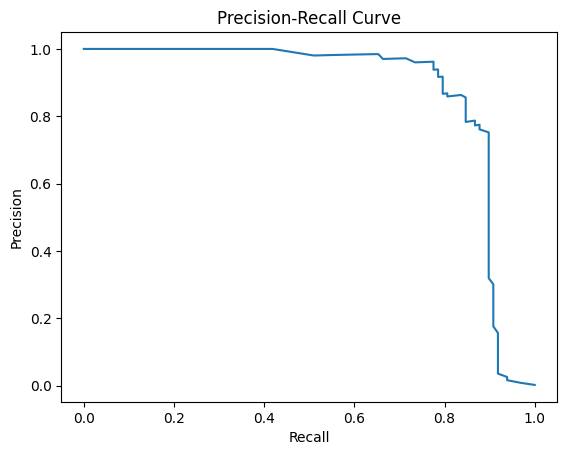

In [ ]:
#Visualizing the Precision–Recall Curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

After threshold tuning, the model achieved very high precision for fraudulent transactions, meaning that when a transaction was flagged as fraud it was correct in the vast majority of cases. The model also maintained a strong recall value, successfully detecting a large proportion of fraudulent transactions.

This balance between precision and recall is important in fraud detection systems. High recall ensures that most fraudulent activities are detected, while high precision reduces the number of legitimate transactions incorrectly flagged as fraud.

The ROC-AUC score further confirms that the model has excellent ability to distinguish between fraudulent and legitimate transactions.

# ***Feature Importance Analysis***

Tree based models like Random Forest measure how useful each feature was for making predictions.

Features that split the data well get higher importance scores.

In [ ]:
#Using the Random Forest model I trained earlier.
importances = rf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

In [ ]:
#Sorting the Features
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
#Viewing the Top Features
print(feature_importance.head(10))

   Feature  Importance
14     V14    0.183715
10     V10    0.111427
4       V4    0.107683
12     V12    0.096535
17     V17    0.086032
11     V11    0.062092
3       V3    0.058436
16     V16    0.053122
2       V2    0.031262
7       V7    0.023408


Above are the most influential fraud indicators.

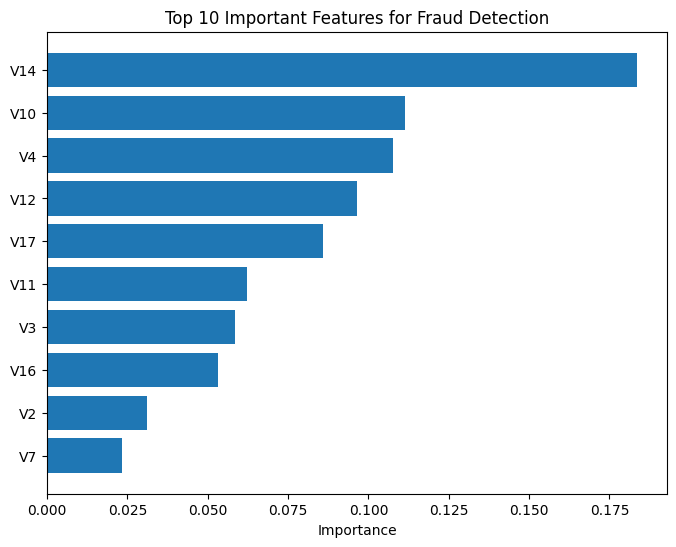

In [ ]:
#Plot of the feature Importance
top_features = feature_importance.head(10)
plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Important Features for Fraud Detection")
plt.show()

Feature importance analysis was performed using the Random Forest model to understand which variables contributed most to fraud detection. The results show that a small number of variables such as V14, V10 and V4 play a significant role in distinguishing fraudulent transactions from normal ones.

# ***Confusion Matrix***

A Confusion Matrix breaks predictions into four groups:

1. True Positive (TP) → fraud correctly detected
2. False Negative (FN) → fraud missed
3. False Positive (FP) → normal transaction flagged as fraud
4. True Negative (TN) → normal transaction correctly classified

For fraud detection, False Negatives are the most dangerous, because that means fraud slipped through.

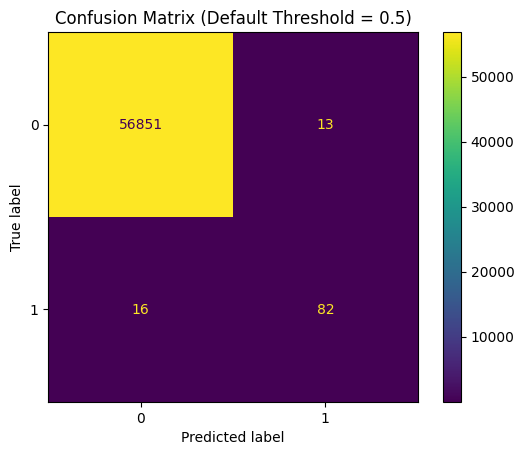

In [22]:
#Confusion Matrix Using Default Threshold (0.5) for the Randmom Forest Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Default prediction
y_pred_default = rf.predict(X_test)
cm_default = confusion_matrix(y_test, y_pred_default)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_default)
disp.plot()
plt.title("Confusion Matrix (Default Threshold = 0.5)")
plt.show()

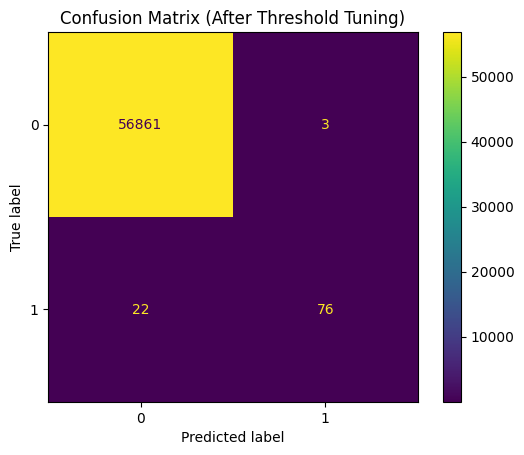

In [23]:
#Confusion Matrix After Threshold Tuning for Random FOrst since best threshold was 0.775
rf_probs = rf.predict_proba(X_test)[:,1]
best_threshold = 0.775
y_pred_tuned = (rf_probs >= best_threshold).astype(int)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tuned)

disp.plot()
plt.title("Confusion Matrix (After Threshold Tuning)")
plt.show()

After applying threshold tuning, the model detected more fraudulent transactions, reducing the number of false negatives. Although this slightly increased false positives, the improvement in fraud detection recall is beneficial because missing fraudulent transactions is typically more costly than investigating additional legitimate transactions.

# ***Overview, Summary, Results and Conclusion***

## Project Overview

This project focused on building a machine learning system capable of detecting fraudulent credit card transactions. Fraud detection is a critical application of machine learning because fraudulent activities are rare but financially damaging. This creates a highly imbalanced classification problem where traditional evaluation metrics such as accuracy can be misleading.

The objective of this project was to develop and evaluate several classification models capable of identifying fraudulent transactions while minimizing false alarms.

Three machine learning algorithms were evaluated in this study: Logistic Regression, Random Forest and XGBoost

The modeling process included handling class imbalance, comparing model performance, and optimizing classification thresholds.


## Methodology Summary

The project followed a structured machine learning workflow.
1. Exploratory data analysis was performed to understand the dataset and confirm the presence of severe class imbalance.
2. The dataset was split into training and testing sets. Baseline models were trained and evaluated using multiple performance metrics including Precision, Recall, F1 Score, and ROC-AUC.
3. To address the imbalance between normal and fraudulent transactions, the SMOTE technique was applied to the training data. This generated synthetic examples of fraudulent transactions, enabling the models to learn fraud patterns more effectively.
4. Finally, threshold tuning was performed to identify a decision boundary that provided an improved balance between detecting fraud and limiting false alarms.


## Key Insights
This project explored the use of machine learning techniques to detect fraudulent credit card transactions in a highly imbalanced dataset. Several important insights emerged from the analysis and modeling process.

1. Class imbalance significantly affects model evaluation: The dataset contains an extremely small proportion of fraudulent transactions compared to legitimate ones. Because of this imbalance, metrics such as Accuracy can give a misleading impression of model performance. Even simple models can achieve very high accuracy by predicting the majority class. Therefore, more informative metrics such as Precision, Recall, and F1 Score were used to properly evaluate model effectiveness.

2. Handling imbalance improves fraud detection capability: Applying SMOTE to balance the training data significantly improved the models’ ability to identify fraudulent transactions. In particular, recall increased across multiple models, meaning the models were able to detect a larger proportion of fraudulent transactions that might otherwise have been missed.

However, this improvement also demonstrated the typical trade-off in fraud detection systems: increasing recall often leads to a higher number of false positives, where legitimate transactions are incorrectly flagged as fraud.

3. Random Forest provided the most balanced performance: Among the evaluated algorithms, Random Forest consistently produced the most balanced performance across precision, recall, and F1 score. This indicates that the model was able to detect fraudulent transactions effectively while maintaining relatively low false positive rates.

Tree-based ensemble models are particularly effective in fraud detection tasks because they can capture complex nonlinear relationships within the data.

4. Threshold tuning helps balance fraud detection and false alarms: Classification models typically use a default probability threshold of 0.5 to determine class labels. However, this default threshold may not be optimal in imbalanced classification problems.

By adjusting the decision threshold using the Precision-Recall Curve, the model achieved a more suitable balance between identifying fraudulent transactions and minimizing false alerts. This step improved the practical usefulness of the model by aligning predictions more closely with the goals of a fraud detection system.

5. High ROC-AUC indicates strong class separation: The high ROC-AUC score observed across the best models suggests that the models are highly capable of distinguishing between fraudulent and legitimate transactions. This indicates that the underlying patterns separating the two classes are well captured by the trained models.


## Results
1. Across all experiments, Random Forest consistently demonstrated strong performance across multiple metrics.
2. Handling class imbalance improved the model’s ability to detect fraudulent transactions, particularly by increasing recall. However, this also highlighted the trade-off between detecting fraud and minimizing false positives.
3. After applying threshold tuning, the final model achieved a strong balance between precision and recall. The model was able to detect the majority of fraudulent transactions while maintaining a very low false positive rate.
4. The high ROC-AUC score further confirmed that the model was highly effective at distinguishing fraudulent transactions from legitimate ones.


## Conclusion
1. This project demonstrates how machine learning can be applied to detect fraudulent financial transactions in highly imbalanced datasets. While baseline models already achieved high accuracy, deeper evaluation revealed the importance of focusing on recall, precision, and F1 score when dealing with rare events such as fraud.
2. Techniques such as SMOTE and threshold tuning significantly improved the model’s ability to detect fraudulent transactions while maintaining reasonable precision.
3. Among the models evaluated, Random Forest provided the best balance between fraud detection capability and prediction reliability. The final optimized model achieved strong performance across multiple evaluation metrics and demonstrated excellent class separation as reflected in its ROC-AUC score.

Overall, this project highlights the importance of careful model evaluation, imbalance handling, and threshold optimization when developing machine learning systems for real-world fraud detection problems.